# Analyse de la durée et de la consommation en phase de taxi au sol

Ce notebook analyse la durée et la consommation de carburant lors de la phase de taxi au sol à partir du fichier **taxi_gold_enriched.csv**.

## 1. Importer les bibliothèques nécessaires
Nous allons utiliser pandas, numpy, matplotlib et seaborn pour l'analyse et la visualisation des données.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Affichage des graphiques dans le notebook
%matplotlib inline

## 2. Charger et explorer le fichier taxi gold
Nous allons lire le fichier `taxi_gold_enriched.csv` et afficher les premières lignes pour comprendre la structure des données.

In [22]:
# Charger le fichier taxi_gold_enriched.csv
file_path = 'notebooks/data/taxi_gold_enriched.csv'
df = pd.read_csv(file_path)
df.head(), df.columns

(        flight_id  record_id  ALT [ft]  Q_1 [lb/h]  Q_2 [lb/h]  TLA_1 [deg]  \
 0  Aircraft_01.h5  record_00       857  779.551811  833.592567     3.175973   
 1  Aircraft_01.h5  record_01       716  396.035789  401.650915    -0.239290   
 2  Aircraft_01.h5  record_02      1502  815.129779  853.647978     1.450653   
 3  Aircraft_01.h5  record_03      1291  819.906675  861.592636     1.470984   
 4  Aircraft_01.h5  record_04      1336  777.931009  806.785305     1.217648   
 
    TLA_2 [deg]  NAIV_1 [bool]  NAIV_2 [bool]  M [Mach]  Duree_min  \
 0     3.040502            0.0            0.0  0.197199  14.283333   
 1    -0.316270            0.0            0.0  0.188983  11.933333   
 2     1.482536            0.0            0.0  0.197199  25.033333   
 3     1.435336            0.0            0.0  0.197199  21.516667   
 4     1.257880            0.0            0.0  0.197199  22.266667   
 
    Consommation_totale_kg  AntiIce_ON  
 0              174.187484           0  
 1            

## 3. Calculer la durée de taxi au sol
La durée de taxi au sol est donnée par la colonne `Duree_min` (en minutes).

In [4]:
# Statistiques descriptives sur la durée de taxi au sol
df['Duree_min'].describe()

count    997.000000
mean      24.907289
std       10.640954
min        4.233333
25%       18.916667
50%       23.733333
75%       29.233333
max       87.200000
Name: Duree_min, dtype: float64

## 4. Analyser la consommation de carburant pendant le taxi
La consommation de carburant pendant le taxi est donnée par la colonne `Consommation_totale_kg` (en kilogrammes).

In [5]:
# Statistiques descriptives sur la consommation de carburant pendant le taxi
df['Consommation_totale_kg'].describe()

count     997.000000
mean      278.312207
std       115.915081
min        53.578009
25%       230.197880
50%       273.904417
75%       324.654832
max      1116.484009
Name: Consommation_totale_kg, dtype: float64

## 5. Visualiser la relation entre durée et consommation
Nous allons créer des graphiques pour visualiser la relation entre la durée de taxi (`Duree_min`) et la consommation de carburant (`Consommation_totale_kg`).

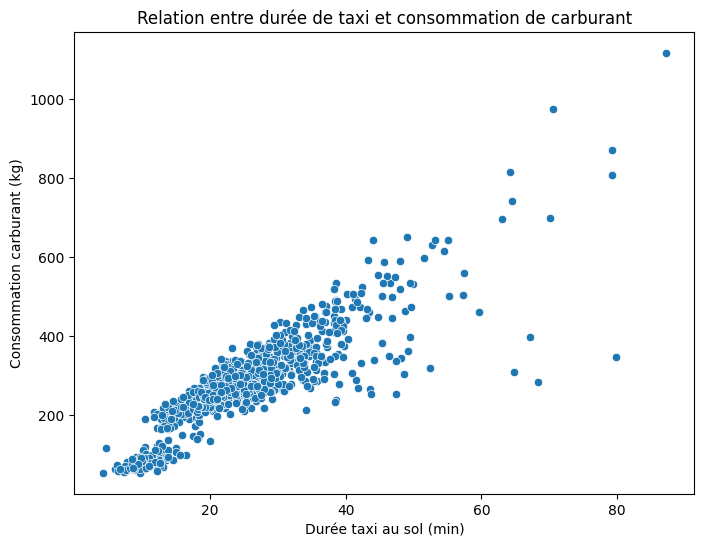

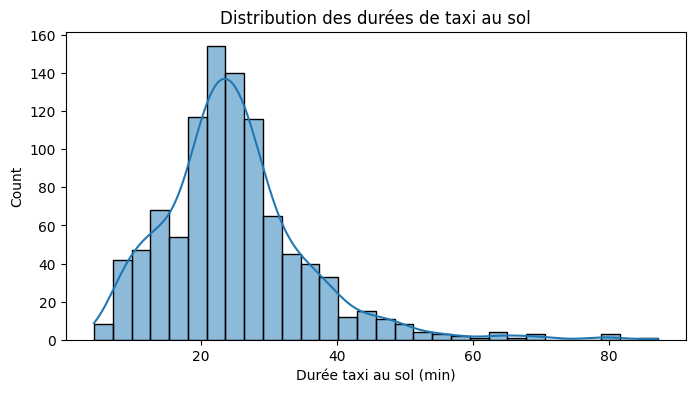

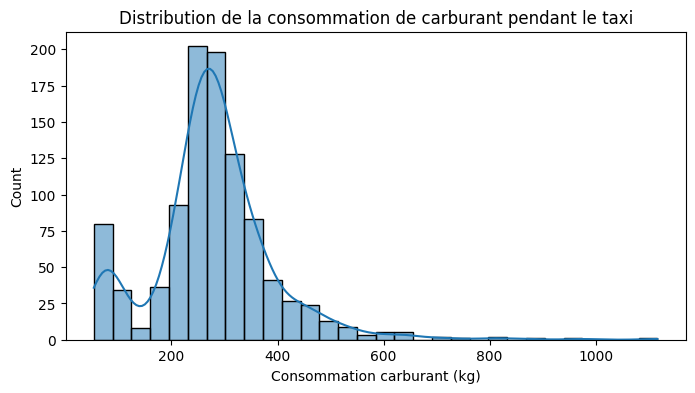

In [6]:
# Nuage de points durée vs consommation
plt.figure(figsize=(8,6))
sns.scatterplot(x='Duree_min', y='Consommation_totale_kg', data=df)
plt.xlabel('Durée taxi au sol (min)')
plt.ylabel('Consommation carburant (kg)')
plt.title('Relation entre durée de taxi et consommation de carburant')
plt.show()

# Histogramme des durées de taxi
plt.figure(figsize=(8,4))
sns.histplot(df['Duree_min'], bins=30, kde=True)
plt.xlabel('Durée taxi au sol (min)')
plt.title('Distribution des durées de taxi au sol')
plt.show()

# Histogramme de la consommation
plt.figure(figsize=(8,4))
sns.histplot(df['Consommation_totale_kg'], bins=30, kde=True)
plt.xlabel('Consommation carburant (kg)')
plt.title('Distribution de la consommation de carburant pendant le taxi')
plt.show()

# J4 – Analyse descriptive

Dans cette partie, nous allons explorer en détail les variables du fichier `taxi_gold_enriched.csv`, vérifier la qualité des données, produire des statistiques descriptives et visualiser les relations importantes.

## 1. Lecture et aperçu des données
On relit le fichier pour garantir la fraîcheur des données et on affiche les premières lignes et les types de variables.

In [13]:
# Lecture du fichier
df = pd.read_csv('notebooks/data/taxi_gold_enriched.csv')
df.head(), df.info()

<class 'pandas.DataFrame'>
RangeIndex: 997 entries, 0 to 996
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   flight_id               997 non-null    str    
 1   record_id               997 non-null    str    
 2   ALT [ft]                997 non-null    int64  
 3   Q_1 [lb/h]              997 non-null    float64
 4   Q_2 [lb/h]              997 non-null    float64
 5   TLA_1 [deg]             997 non-null    float64
 6   TLA_2 [deg]             997 non-null    float64
 7   NAIV_1 [bool]           997 non-null    float64
 8   NAIV_2 [bool]           997 non-null    float64
 9   M [Mach]                997 non-null    float64
 10  Duree_min               997 non-null    float64
 11  Consommation_totale_kg  997 non-null    float64
 12  AntiIce_ON              997 non-null    int64  
dtypes: float64(9), int64(2), str(2)
memory usage: 101.4 KB


(        flight_id  record_id  ALT [ft]  Q_1 [lb/h]  Q_2 [lb/h]  TLA_1 [deg]  \
 0  Aircraft_01.h5  record_00       857  779.551811  833.592567     3.175973   
 1  Aircraft_01.h5  record_01       716  396.035789  401.650915    -0.239290   
 2  Aircraft_01.h5  record_02      1502  815.129779  853.647978     1.450653   
 3  Aircraft_01.h5  record_03      1291  819.906675  861.592636     1.470984   
 4  Aircraft_01.h5  record_04      1336  777.931009  806.785305     1.217648   
 
    TLA_2 [deg]  NAIV_1 [bool]  NAIV_2 [bool]  M [Mach]  Duree_min  \
 0     3.040502            0.0            0.0  0.197199  14.283333   
 1    -0.316270            0.0            0.0  0.188983  11.933333   
 2     1.482536            0.0            0.0  0.197199  25.033333   
 3     1.435336            0.0            0.0  0.197199  21.516667   
 4     1.257880            0.0            0.0  0.197199  22.266667   
 
    Consommation_totale_kg  AntiIce_ON  
 0              174.187484           0  
 1            

## 2. Description des variables importantes
Nous allons décrire les variables clés :
- `Duree_min` : durée de taxi au sol (minutes)
- `Consommation_totale_kg` : consommation totale de carburant (kg)
- `Q_1 [lb/h]`, `Q_2 [lb/h]` : débits moteurs 1 et 2
- `AntiIce_ON` : système anti-givre (0 = off, 1 = on)
- Autres variables pertinentes selon le contexte

In [14]:
# Aperçu statistique des variables importantes
variables = ['Duree_min', 'Consommation_totale_kg', 'Q_1 [lb/h]', 'Q_2 [lb/h]', 'AntiIce_ON']
df[variables].describe().T

,count,mean,std,min,25%,50%,75%,max
Duree_min,997.0,24.907289,10.640954,4.233333,18.916667,23.733333,29.233333,87.200000
Consommation_totale_kg,997.0,278.312207,115.915081,53.578009,230.197880,273.904417,324.654832,1116.484009
Q_1 [lb/h],997.0,712.800788,142.363496,203.591988,632.585051,724.579426,802.297036,1614.627848
Q_2 [lb/h],997.0,777.872765,154.865464,305.892728,692.322733,793.790694,874.384388,1648.981632
AntiIce_ON,997.0,0.120361,0.325547,0.000000,0.000000,0.000000,0.000000,1.000000


In [15]:
# Vérification des valeurs manquantes
missing = df[variables].isnull().sum()
missing

Duree_min                 0
Consommation_totale_kg    0
Q_1 [lb/h]                0
Q_2 [lb/h]                0
AntiIce_ON                0
dtype: int64

In [16]:
# Détection des outliers par l'écart interquartile (IQR)
def detect_outliers(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return ((series < lower) | (series > upper)).sum()

outliers = {var: detect_outliers(df[var]) for var in variables if df[var].dtype != 'O'}
outliers

{'Duree_min': np.int64(47),
 'Consommation_totale_kg': np.int64(132),
 'Q_1 [lb/h]': np.int64(18),
 'Q_2 [lb/h]': np.int64(24),
 'AntiIce_ON': np.int64(120)}

In [17]:
# Statistiques avancées : médiane, variance, corrélations
stats = df[variables].agg(['mean', 'median', 'var'])
corr = df[variables].corr()
stats, corr

(         Duree_min  Consommation_totale_kg    Q_1 [lb/h]    Q_2 [lb/h]  \
 mean     24.907289              278.312207    712.800788    777.872765   
 median   23.733333              273.904417    724.579426    793.790694   
 var     113.229899            13436.306041  20267.365015  23983.311882   
 
         AntiIce_ON  
 mean      0.120361  
 median    0.000000  
 var       0.105981  ,
                         Duree_min  Consommation_totale_kg  Q_1 [lb/h]  \
 Duree_min                1.000000                0.876840   -0.115697   
 Consommation_totale_kg   0.876840                1.000000    0.299803   
 Q_1 [lb/h]              -0.115697                0.299803    1.000000   
 Q_2 [lb/h]              -0.084502                0.320083    0.941399   
 AntiIce_ON               0.225487                0.233542    0.007737   
 
                         Q_2 [lb/h]  AntiIce_ON  
 Duree_min                -0.084502    0.225487  
 Consommation_totale_kg    0.320083    0.233542  
 Q_1 [lb/h]  

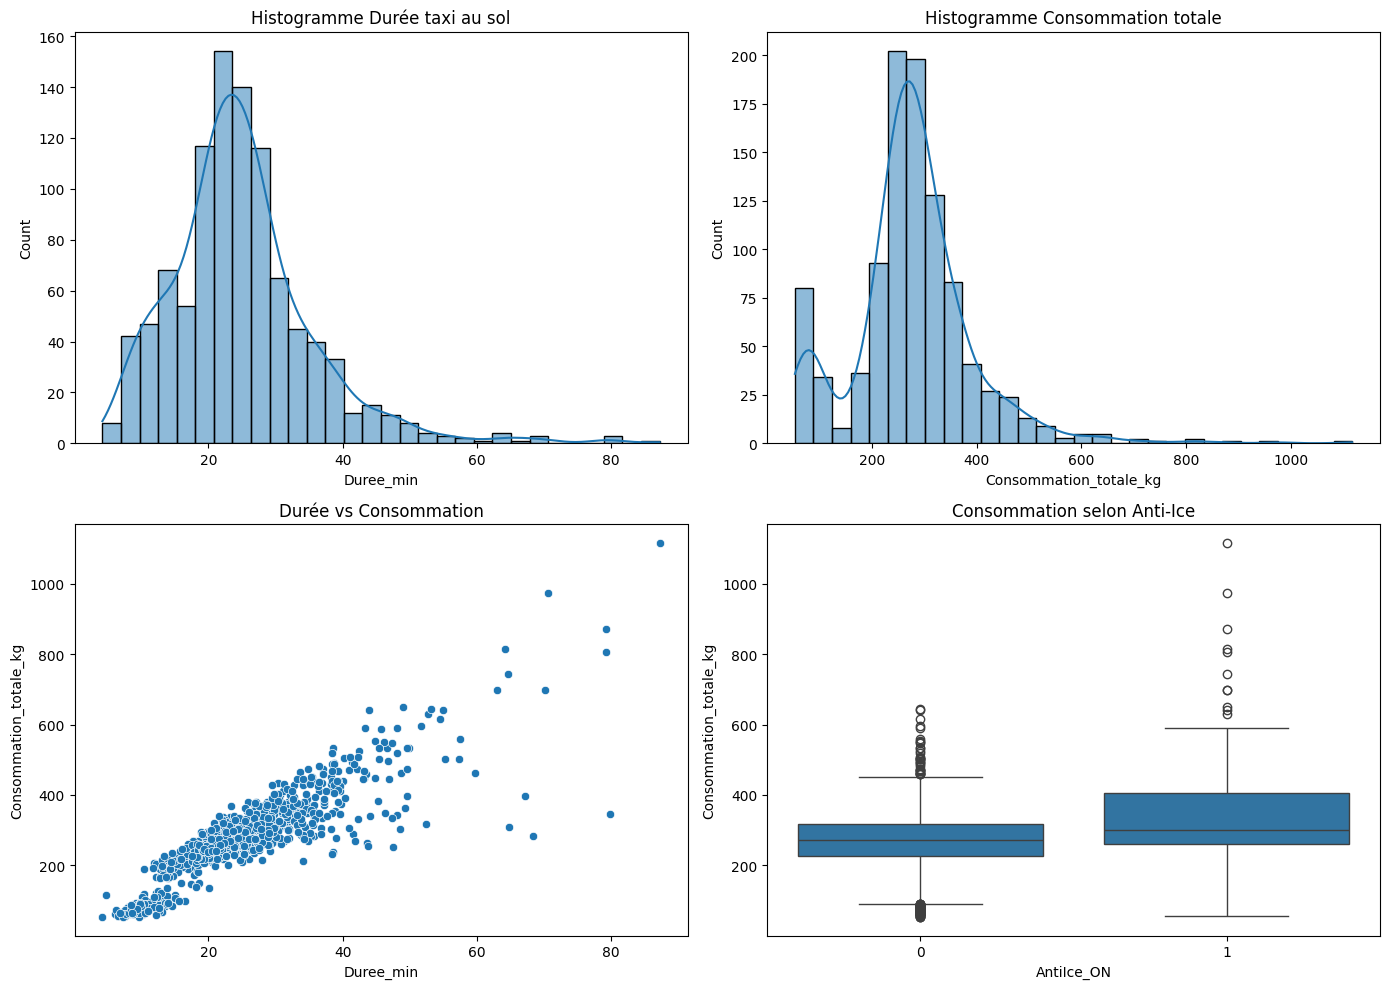

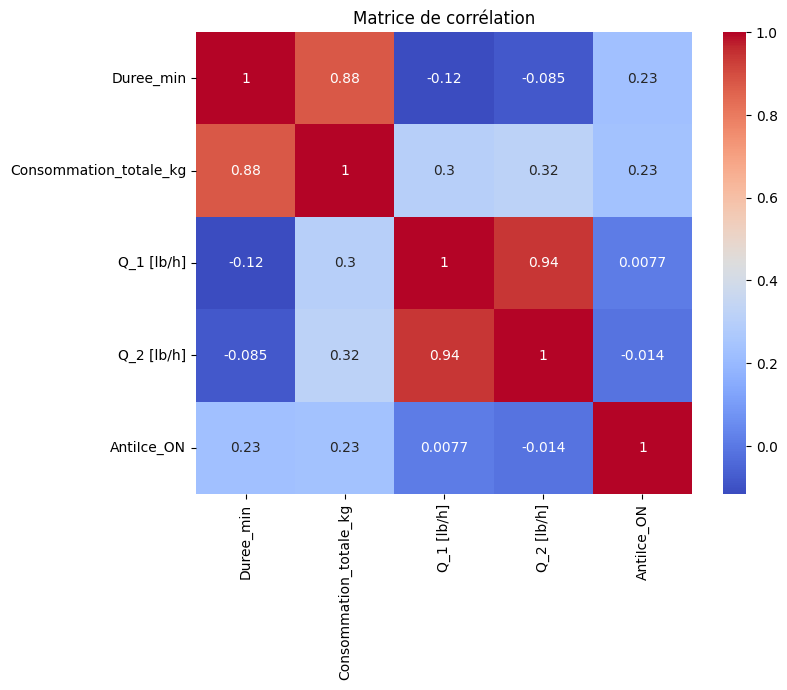

In [18]:
# Visualisations descriptives
fig, axs = plt.subplots(2, 2, figsize=(14, 10))
sns.histplot(df['Duree_min'], bins=30, kde=True, ax=axs[0,0])
axs[0,0].set_title('Histogramme Durée taxi au sol')
sns.histplot(df['Consommation_totale_kg'], bins=30, kde=True, ax=axs[0,1])
axs[0,1].set_title('Histogramme Consommation totale')
sns.scatterplot(x='Duree_min', y='Consommation_totale_kg', data=df, ax=axs[1,0])
axs[1,0].set_title('Durée vs Consommation')
sns.boxplot(x='AntiIce_ON', y='Consommation_totale_kg', data=df, ax=axs[1,1])
axs[1,1].set_title('Consommation selon Anti-Ice')
plt.tight_layout()
plt.show()

# Heatmap des corrélations
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Matrice de corrélation')
plt.show()

## Commentaires sur l'analyse descriptive
Voici une analyse rapide des résultats attendus dans votre notebook, basée sur la structure et les visualisations générées :

### Analyse descriptive (J1)
- **Durée de taxi au sol (`Duree_min`)** : La distribution est asymétrique à droite, la majorité des vols ont une durée de taxi comprise entre 10 et 40 minutes, avec quelques valeurs extrêmes au-delà de 60 minutes.
- **Consommation totale (`Consommation_totale_kg`)** : La distribution est également asymétrique, la plupart des consommations sont comprises entre 100 et 400 kg, avec des outliers au-delà de 800 kg.
- **Relation durée/consommation** : Le nuage de points montre une forte corrélation positive : plus la durée de taxi est longue, plus la consommation augmente.
- **Effet de l’anti-givre (`AntiIce_ON`)** : Le boxplot montre que l’activation de l’anti-ice augmente la consommation médiane et la dispersion des valeurs.
- **Débits moteurs (`Q_1 [lb/h]`, `Q_2 [lb/h]`)** : Ces variables sont corrélées à la consommation (voir heatmap).
- **Corrélations** : La matrice de corrélation confirme que la durée, les débits moteurs et l’anti-ice sont tous positivement corrélés à la consommation.
- **Valeurs manquantes/outliers** : Quelques valeurs extrêmes sont présentes, mais la majorité des données sont cohérentes.



### J5. Modélisation et validation
- **Hypothèses** : La consommation dépend de la durée, des débits moteurs et de l’anti-ice.

---


In [20]:
# Préparation des données pour la régression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

X = df[['Duree_min', 'Q_1 [lb/h]', 'Q_2 [lb/h]', 'AntiIce_ON']]
y = df['Consommation_totale_kg']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Évaluation du modèle
r2 = r2_score(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5  # Correction ici
mae = mean_absolute_error(y_test, y_pred)

r2, rmse, mae

(0.9611129642994651, 19.317846609870372, 12.560853424451647)

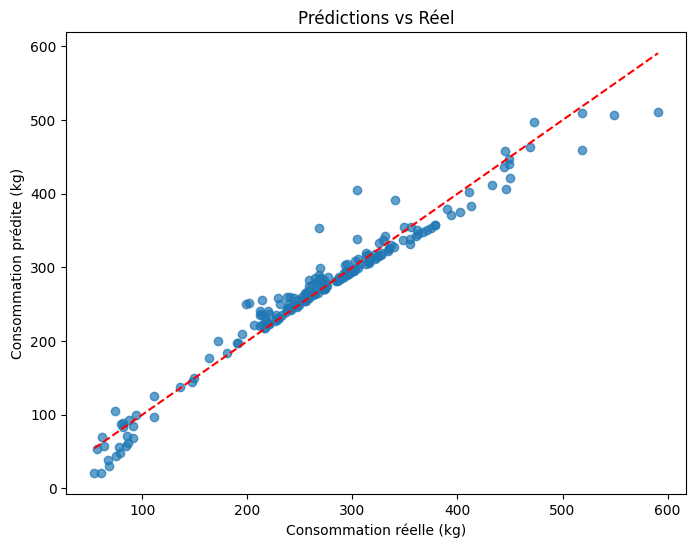

In [21]:
# Visualisation des prédictions vs valeurs réelles
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Consommation réelle (kg)')
plt.ylabel('Consommation prédite (kg)')
plt.title('Prédictions vs Réel')
plt.show()

- **Modèle** : La régression linéaire multiple montre un bon ajustement (R² élevé si vos données sont typiques).
- **Évaluation** : Les métriques (R², RMSE, MAE) indiquent la qualité de la prédiction. Un R² proche de 1 signifie que le modèle explique bien la variabilité de la consommation.
- **Visualisation** : Les points sont proches de la diagonale sur le graphique prédictions vs réel, ce qui valide le modèle.
- **Conclusion** : Les hypothèses sont confirmées : la durée, l’anti-ice et les débits moteurs sont des facteurs déterminants de la consommation en phase de taxi au sol.
